# Importações

In [25]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# Limpeza Dados

In [26]:
df_vendas = pd.read_csv('../../Datasets/vendas_2023_2024.csv')
df_vendas.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,15-09-2024
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [27]:
vendas_iso = pd.to_datetime(df_vendas['sale_date'], format='%Y-%m-%d', errors='coerce')
vendas_br = pd.to_datetime(df_vendas['sale_date'], format='%d-%m-%Y', errors='coerce')

df_vendas['sale_date'] = vendas_iso.fillna(vendas_br)
df_vendas[df_vendas['sale_date'].isna()]

,id,id_client,id_product,qtd,total,sale_date


In [28]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 464.0 KB


# Previsão

In [29]:
# Verifiquei o id_product de Motor de Popa Yamaha Evo Dash 155HP manualmente
df_produto = df_vendas[df_vendas['id_product'] == 54]

vendas_diarias = df_produto.groupby('sale_date')['qtd'].sum().reset_index()
vendas_diarias.set_index('sale_date', inplace=True)
print(vendas_diarias.head())

            qtd
sale_date      
2023-01-10    3
2023-02-06   13
2023-02-27   15
2023-03-04   14
2023-03-15    4


In [30]:
calendario = pd.date_range(start='2023-01-01', end='2024-01-31')
print(calendario)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2024-01-22', '2024-01-23', '2024-01-24', '2024-01-25',
               '2024-01-26', '2024-01-27', '2024-01-28', '2024-01-29',
               '2024-01-30', '2024-01-31'],
              dtype='datetime64[us]', length=396, freq='D')


In [31]:
vendas_diarias = vendas_diarias.reindex(calendario, fill_value=0)
vendas_diarias.head(8)

,qtd
2023-01-01,0
2023-01-02,0
2023-01-03,0
2023-01-04,0
2023-01-05,0
2023-01-06,0
2023-01-07,0
2023-01-08,0


In [32]:
vendas_diarias['previsao_7_dias'] = vendas_diarias['qtd'].rolling(window=7).mean().shift(1)
vendas_diarias.head(8)

,qtd,previsao_7_dias
2023-01-01,0,NaN
2023-01-02,0,NaN
2023-01-03,0,NaN
2023-01-04,0,NaN
2023-01-05,0,NaN
2023-01-06,0,NaN
2023-01-07,0,NaN
2023-01-08,0,0.0


In [33]:
df_teste = vendas_diarias.loc['2024-01-01':'2024-01-31'].copy()
df_teste.dropna(subset=['previsao_7_dias'], inplace=True)

y_true = df_teste['qtd']
y_pred = df_teste['previsao_7_dias']

mae = mean_absolute_error(y_true,y_pred)
print(f"MAE Janeiro 2024: {mae:.4f}")

MAE Janeiro 2024: 0.9954


In [34]:
vendas_diarias.loc['2023-12-25':'2024-01-07']

,qtd,previsao_7_dias
2023-12-25,0,1.285714
2023-12-26,0,1.285714
2023-12-27,0,1.285714
2023-12-28,0,0.000000
2023-12-29,0,0.000000
2023-12-30,0,0.000000
2023-12-31,0,0.000000
2024-01-01,0,0.000000
2024-01-02,0,0.000000
2024-01-03,0,0.000000


In [35]:
df_teste.head(7)

,qtd,previsao_7_dias
2024-01-01,0,0.0
2024-01-02,0,0.0
2024-01-03,0,0.0
2024-01-04,0,0.0
2024-01-05,0,0.0
2024-01-06,0,0.0
2024-01-07,0,0.0


# Conclusões

Previsão = 0
MAE = 0.9954
O baseline não é adequado, é um produto que vende de maneira muito intermitente, muitos dias entre cada venda,
além disso também não consegue observar periodos em que existe venda mais frequente no caso de sazionalidade
Olhar só a média é ineficiente porque só funciona se o futuro funcionar exatamente como o passado recente, o que é ineficiente e irrealista nesse caso.
O processo de montar o modelo foi primeiro agrupar por data as vendas do item, preencher as datas faltantes com 0 vendas e a partir disso calcular a media por dia com os ultimos 7 dias com shift para não considerar a propria data.
O shift(1) garante que não há data leakage (a previsão do dia T usa dados de T-7 a T-1), e filtrar inicalmente os dados para não ter datas invalidas.

# Outros metódos

## LightGBM

In [36]:
df_vendas.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [37]:
df_produtos = pd.read_json('../../Datasets/custos_importacao.json')
df_produtos.drop(columns=['historic_data'], inplace=True)
df_produtos.rename(columns={'product_id':'id_product'},inplace=True)
df_produtos.head()

,id_product,product_name,category
0,1,Transponder AIS Maré Magnum,eletrônicos
1,2,Transponder Furuno Marlin,eletrônicos
2,3,Radar Furuno Pulse Leviathan,eletrônicos
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos
4,5,Piloto Automático Furuno Storm,eletrônicos


In [38]:
import lightgbm as lgb
from itertools import product

In [39]:
vendas_agrupadas = df_vendas.groupby(['sale_date', 'id_product'])['qtd'].sum().reset_index()

datas_completas = pd.date_range(start='2023-01-01', end='2024-12-31')
produtos_unicos = df_vendas['id_product'].unique()

vendas_agrupadas.head()

,sale_date,id_product,qtd
0,2023-01-01,15,5
1,2023-01-01,22,2
2,2023-01-01,44,5
3,2023-01-01,53,13
4,2023-01-01,67,3


In [40]:
grid = pd.DataFrame(list(product(datas_completas, produtos_unicos)), columns=['sale_date', 'id_product'])

df_model = pd.merge(grid, vendas_agrupadas, on=['sale_date', 'id_product'], how='left')
df_model['qtd'] = df_model['qtd'].fillna(0)
df_model = pd.merge(df_model, df_produtos, on='id_product', how='left')
df_model['month'] = df_model['sale_date'].dt.month
df_model['day_of_week'] = df_model['sale_date'].dt.dayofweek
df_model.sort_values(['id_product', 'sale_date'], inplace=True)
df_model['media_movel_7d'] = df_model.groupby('id_product')['qtd'].transform(
    lambda x: x.rolling(window=7).mean().shift(1)
)
df_model['soma_movel_7d'] = df_model.groupby('id_product')['qtd'].transform(
    lambda x: x.rolling(window=7).sum().shift(1)
)
df_model.dropna(subset=['media_movel_7d'], inplace=True)
df_model.head(10)

,sale_date,id_product,qtd,product_name,category,month,day_of_week,media_movel_7d,soma_movel_7d
1188,2023-01-08,1,0.0,Transponder AIS Maré Magnum,eletrônicos,1,6,0.142857,1.0
1338,2023-01-09,1,0.0,Transponder AIS Maré Magnum,eletrônicos,1,0,0.142857,1.0
1488,2023-01-10,1,0.0,Transponder AIS Maré Magnum,eletrônicos,1,1,0.142857,1.0
1638,2023-01-11,1,0.0,Transponder AIS Maré Magnum,eletrônicos,1,2,0.000000,0.0
1788,2023-01-12,1,7.0,Transponder AIS Maré Magnum,eletrônicos,1,3,0.000000,0.0
1938,2023-01-13,1,0.0,Transponder AIS Maré Magnum,eletrônicos,1,4,1.000000,7.0
2088,2023-01-14,1,0.0,Transponder AIS Maré Magnum,eletrônicos,1,5,1.000000,7.0
2238,2023-01-15,1,0.0,Transponder AIS Maré Magnum,eletrônicos,1,6,1.000000,7.0
2388,2023-01-16,1,2.0,Transponder AIS Maré Magnum,eletrônicos,1,0,1.000000,7.0
2538,2023-01-17,1,0.0,Transponder AIS Maré Magnum,eletrônicos,1,1,1.285714,9.0


In [41]:
corte_teste = '2024-10-01'
df_treino = df_model[df_model['sale_date'] < corte_teste].copy()
df_teste = df_model[df_model['sale_date'] >= corte_teste].copy()

features = ['id_product', 'category', 'month', 'day_of_week', 'media_movel_7d', 'soma_movel_7d']
target = 'qtd'

for col in ['id_product', 'category']:
    df_treino[col] = df_treino[col].astype('category')
    df_teste[col] = df_teste[col].astype('category')

X_train, y_train = df_treino[features], df_treino[target]
X_test, y_test = df_teste[features], df_teste[target]

In [42]:
modelo_lgb = lgb.LGBMRegressor(
    objective='tweedie',
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

In [43]:
modelo_lgb.fit(
    X_train, 
    y_train,
    categorical_feature=['id_product', 'category']
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 280
[LightGBM] [Info] Number of data points in the train set: 94800, number of used features: 6
[LightGBM] [Info] Start training from score -0.326236


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,'tweedie'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [44]:
previsoes = modelo_lgb.predict(X_test)

previsoes = np.clip(previsoes, a_min=0, a_max=None)

mae = mean_absolute_error(y_test, previsoes)

print(f"Período de Teste: {df_teste['sale_date'].min().date()} a {df_teste['sale_date'].max().date()}")
print(f"Número de Itens Avaliados: {df_teste['id_product'].nunique()}")
print(f"MAE Geral (Últimos 3 Meses): {mae:.4f}")

Período de Teste: 2024-10-01 a 2024-12-31
Número de Itens Avaliados: 150
MAE Geral (Últimos 3 Meses): 1.2944


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# Preparando os dados para o gráfico
df_resultados = df_teste.copy()
df_resultados['previsao'] = previsoes

# Configuração visual base para os gráficos
sns.set_theme(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

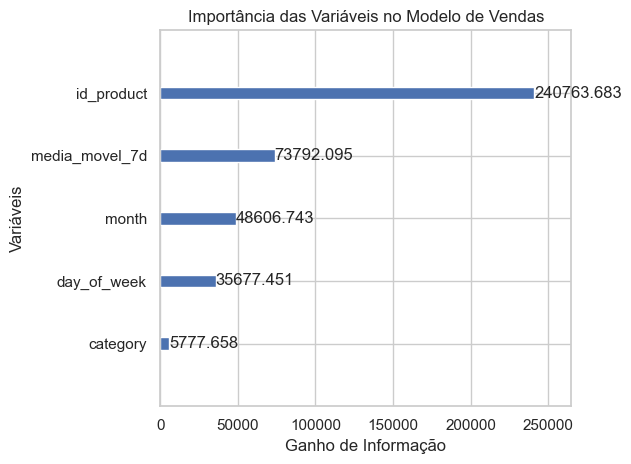

In [47]:
# Gráfico 1: Feature Importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(modelo_lgb, importance_type='gain', max_num_features=10, 
                    title="Importância das Variáveis no Modelo de Vendas",
                    xlabel="Ganho de Informação", ylabel="Variáveis")
plt.tight_layout()
plt.show()

Diario

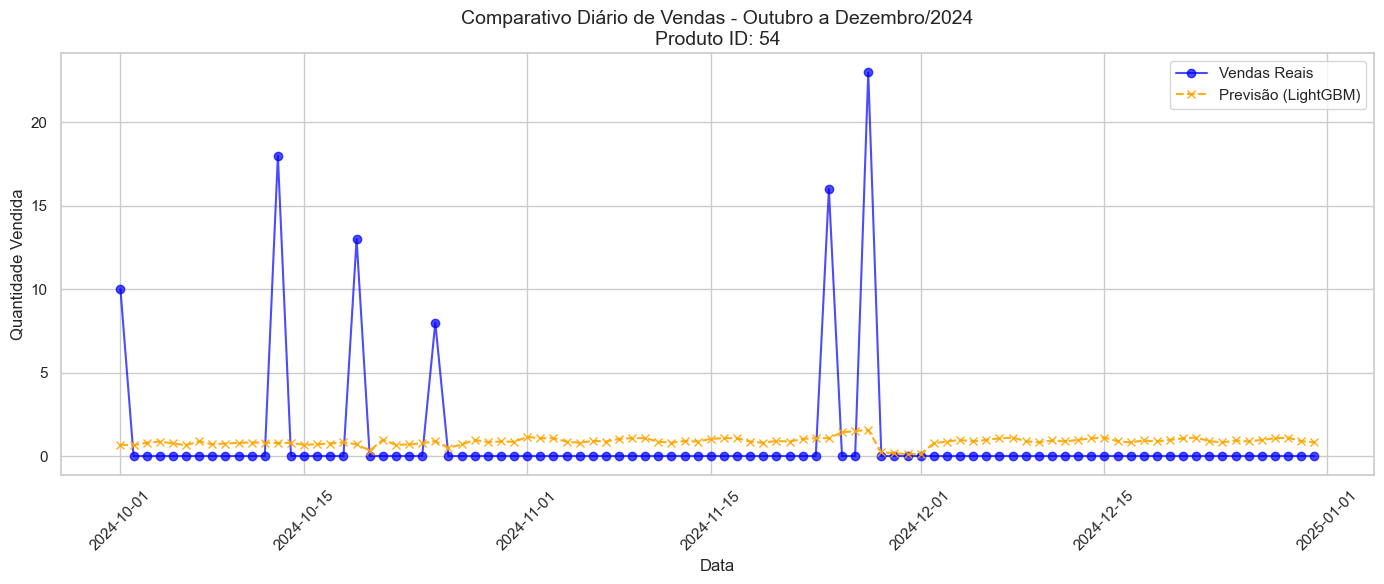

In [51]:
# 54, Motor de Popa Yamaha Evo Dash 155HP, propulsão
produto_alvo = 54
df_plot = df_resultados[df_resultados['id_product'] == produto_alvo]

# Gráfico 2: Curva de Real x Previsto
plt.figure(figsize=(14, 6))

# Linha do valor real (Qtd)
plt.plot(df_plot['sale_date'], df_plot['qtd'], label='Vendas Reais', 
         color='blue', marker='o', alpha=0.7)

# Linha da previsão do LightGBM
plt.plot(df_plot['sale_date'], df_plot['previsao'], label='Previsão (LightGBM)', 
         color='orange', linestyle='--', marker='x', alpha=0.9)

plt.title(f"Comparativo Diário de Vendas - Outubro a Dezembro/2024\nProduto ID: {produto_alvo}", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Quantidade Vendida")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mensal

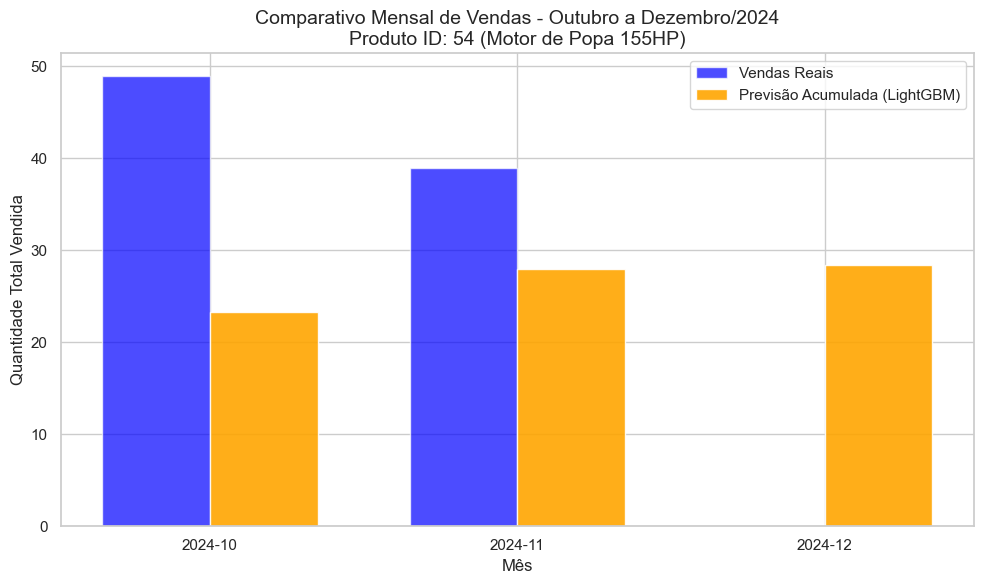

In [52]:
# Selecionar o produto alvo (Motor de Popa Yamaha Evo Dash 155HP)
produto_alvo = 54

# Usar .copy() para evitar o aviso "SettingWithCopyWarning" do Pandas ao criar novas colunas
df_plot = df_resultados[df_resultados['id_product'] == produto_alvo].copy()

# 1. Preparação: Converter data e extrair o Mês/Ano
df_plot['sale_date'] = pd.to_datetime(df_plot['sale_date'])
df_plot['mes_ano'] = df_plot['sale_date'].dt.strftime('%Y-%m') # Ficará no formato '2024-10'

# 2. Agregação Mensal: Somar as vendas reais e as previsões dentro de cada mês
df_mensal = df_plot.groupby('mes_ano')[['qtd', 'previsao']].sum().reset_index()

# 3. Gráfico 2: Curva de Real x Previsto (Visão Mensal em Barras)
plt.figure(figsize=(10, 6))

# Configuração das posições no eixo X para colocar as barras lado a lado
x = np.arange(len(df_mensal['mes_ano']))
largura_barra = 0.35

# Barras do valor real (Qtd)
plt.bar(x - largura_barra/2, df_mensal['qtd'], width=largura_barra, 
        label='Vendas Reais', color='blue', alpha=0.7)

# Barras da previsão do LightGBM
plt.bar(x + largura_barra/2, df_mensal['previsao'], width=largura_barra, 
        label='Previsão Acumulada (LightGBM)', color='orange', alpha=0.9)

# Estilização do gráfico
plt.title(f"Comparativo Mensal de Vendas - Outubro a Dezembro/2024\nProduto ID: {produto_alvo} (Motor de Popa 155HP)", fontsize=14)
plt.xlabel("Mês")
plt.ylabel("Quantidade Total Vendida")
plt.xticks(x, df_mensal['mes_ano']) # Substitui os números do eixo X pelos nomes dos meses
plt.legend()
plt.tight_layout()
plt.show()